<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509Files/blob/main/OPIM5509_Module5_Files/notebooks/6_2_understanding_recurrent_neural_networks.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS — M5 · 9 — Embeddings into recurrent layers: SimpleRNN -> LSTM on IMDB
- The bridge from M4: a review of 100 words, each embedded as 32 numbers, IS a time series of 100 steps x 32 features. Same recurrent layers, read oldest word to newest.
- Count first: Embedding(10000, 32) = 320,000. SimpleRNN(32) = (32 + 32) x 32 + 32 = 2,080 -> 322,080. return_sequences=True SimpleRNN(50): 4,150. Four stacked: 366,000.
- IMDB: 25,000 train and 25,000 test reviews, top 10,000 words, each cut to 100 words.
- SimpleRNN(64): 326,273 parameters. Validation accuracy bounces 0.71-0.81 - read the loss curve. TEST MACRO F1 0.789.
- LSTM(64, return_sequences=True) -> GRU(32): 1,338,849 parameters. TEST MACRO F1 0.812.
- Where do the parameters live? The embedding: 1,280,000 of 1,338,849 (96%). The 'thinking' layers are tiny.
- Scoreboard so far: 0.789 -> 0.812. Every model gets the same test-set cell, same metric as the capstone.
-->

# Understanding recurrent neural networks

--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

This notebook contains the code samples found in Chapter 6, Section 2 of [Deep Learning with Python](https://www.manning.com/books/deep-learning-with-python?a_aid=keras&a_bid=76564dff). Note that the original text features far more content, in particular further explanations and figures: in this notebook, you will only find source code and related comments.

---

[...]

## A first recurrent layer in Keras

The process we just naively implemented in Numpy corresponds to an actual Keras layer: the `SimpleRNN` layer:


In [1]:
import keras
keras.__version__

'3.15.1'

In [2]:
# seed everything: same numbers on my screen and yours
# (and we re-seed right before every model build, so model 2 is as reproducible as model 1)
import keras
import tensorflow as tf

keras.utils.set_random_seed(5509)
tf.config.experimental.enable_op_determinism()

In [3]:
from keras.layers import SimpleRNN

There is just one minor difference: `SimpleRNN` processes batches of sequences, like all other Keras layers, not just a single sequence like
in our Numpy example. This means that it takes inputs of shape `(batch_size, timesteps, input_features)`, rather than `(timesteps,
input_features)`.

Like all recurrent layers in Keras, `SimpleRNN` can be run in two different modes: it can return either the full sequences of successive
outputs for each timestep (a 3D tensor of shape `(batch_size, timesteps, output_features)`), or it can return only the last output for each
input sequence (a 2D tensor of shape `(batch_size, output_features)`). These two modes are controlled by the `return_sequences` constructor
argument. Let's take a look at an example:

In [4]:
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN
from keras.layers import Input

model = Sequential()
model.add(Input(shape=(None,)))  # any sequence length
model.add(Embedding(10000, 32)) # 10000 max words, each with a 32 dim representation
model.add(SimpleRNN(32))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 32)       │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,080 (1.23 MB)

 Trainable params: 322,080 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
from keras.layers import Input
model = Sequential()
model.add(Input(shape=(None,)))  # any sequence length
model.add(Embedding(10000, 32))
model.add(SimpleRNN(50, return_sequences=True))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, None, 32)       │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, None, 50)       │         4,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 324,150 (1.24 MB)

 Trainable params: 324,150 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

It is sometimes useful to stack several recurrent layers one after the other in order to increase the representational power of a network.
In such a setup, you have to get all intermediate layers to return full sequences:

In [6]:
from keras.layers import Input
model = Sequential()
model.add(Input(shape=(None,)))  # any sequence length
model.add(Embedding(10000, 32))
model.add(SimpleRNN(100, return_sequences=True))
model.add(SimpleRNN(100, return_sequences=True))
model.add(SimpleRNN(50, return_sequences=True))
model.add(SimpleRNN(50))  # This last layer only returns the last outputs.
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, None, 32)       │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, None, 100)      │        13,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, None, 100)      │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, None, 50)       │         7,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 50)             │         5,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 366,000 (1.40 MB)

 Trainable params: 366,000 (1.40 MB)

 Non-trainable params: 0 (0.00 B)

Now let's try to use such a model on the IMDB movie review classification problem. First, let's preprocess the data:

In [7]:
from keras.datasets import imdb
from keras.utils import pad_sequences

max_features = 10000  # number of words to consider as features
maxlen = 100  # cut texts after this number of words (among top max_features most common words)
batch_size = 50

print('Loading data...')
(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words=max_features)
print(len(input_train), 'train sequences')
print(len(input_test), 'test sequences')

print('Pad sequences (samples x time)')
input_train = pad_sequences(input_train, maxlen=maxlen)
input_test = pad_sequences(input_test, maxlen=maxlen)
print('input_train shape:', input_train.shape)
print('input_test shape:', input_test.shape)

Loading data...


25000 train sequences
25000 test sequences
Pad sequences (samples x time)


input_train shape: (25000, 100)
input_test shape: (25000, 100)


In [8]:
input_train[322]

array([  86,   95, 5996,  254,    8,  106, 1841,    4,  130,   13, 1695,
        397, 4735,   54,    4, 2325, 5339,   19, 5632,  986,    2, 2371,
         83,    4,  936,    2,  121,  263,   62,   30, 1886, 1902, 1153,
          5, 5531,    2,   19, 9038,   10,   10,    4,  114,    6,  255,
        209, 1804,   11,  558,  778, 5611,    4, 6367,    7, 2890,    4,
          2,    5,    9,    2,    5, 3072,   44,    4, 7021,    6, 2325,
          9, 1412,  730,   39,    4,    2,    8, 3928,    4,  420,    9,
       5413, 4031,   34, 4168,   42,    6,    2,   18, 1954, 2890,   10,
         10,    4,   64, 4631,   11,   14,   22,    9,   15,   12,  417,
        630], dtype=int32)

Let's train a simple recurrent network using an `Embedding` layer and a `SimpleRNN` layer:

In [9]:
from keras.layers import Dense
from keras.layers import Input

keras.utils.set_random_seed(5509)   # re-seed right before the build: same starting weights every run
model = Sequential()
model.add(Input(shape=(maxlen,)))
model.add(Embedding(max_features, 32)) #max_features = max_words you kept (10k), 32d embedding, keep first 100 words
model.add(SimpleRNN(64)) # this layer 'spins' 100 times and has 64 red dots
model.add(Dense(1, activation='sigmoid'))
model.summary()

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(input_train, y_train,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.2)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,273 (1.24 MB)

 Trainable params: 326,273 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

...

148/157 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9897 - loss: 0.0320

151/157 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9899 - loss: 0.0315

153/157 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9899 - loss: 0.0312

155/157 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9900 - loss: 0.0312

157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - acc: 0.9900 - loss: 0.0313 - val_acc: 0.7800 - val_loss: 0.8755


Let's display the training and validation loss and accuracy:

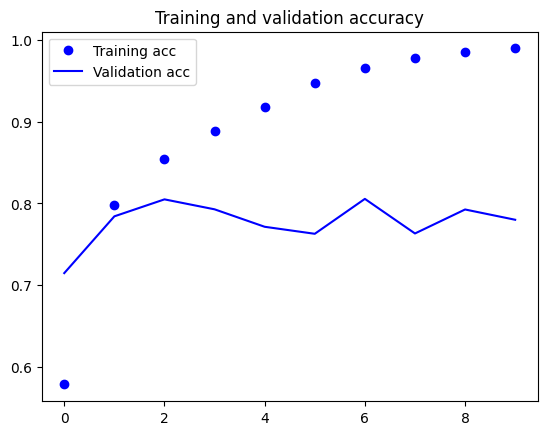

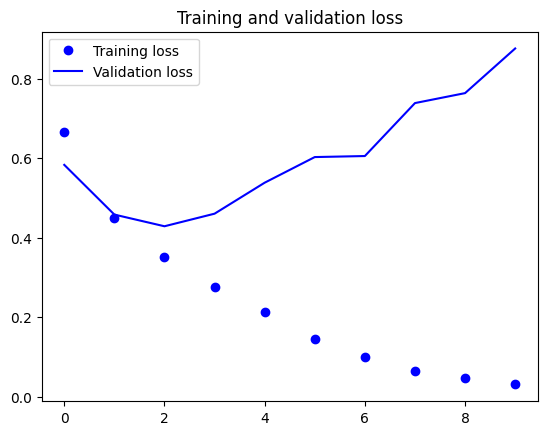

In [10]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [11]:
# score it on the TEST set - macro F1 is how we compare models (same as the capstone)
from sklearn.metrics import f1_score

probs = model.predict(input_test, verbose=0)
preds = (probs > 0.5).astype(int).ravel()
print('SimpleRNN  test macro F1:', round(f1_score(y_test, preds, average='macro'), 3))

SimpleRNN  test macro F1: 0.789


As a reminder, in chapter 3, our very first naive approach to this very dataset got us to 88% test accuracy. Unfortunately, our small
recurrent network doesn't perform very well at all compared to this baseline (only up to 85% validation accuracy). Part of the problem is
that our inputs only consider the first 500 words rather the full sequences --
hence our RNN has access to less information than our earlier baseline model. The remainder of the problem is simply that `SimpleRNN` isn't very good at processing long sequences, like text. Other types of recurrent layers perform much better. Let's take a look at some
more advanced layers.

[...]

## A concrete LSTM example in Keras

Now let's switch to more practical concerns: we will set up a model using a LSTM layer and train it on the IMDB data. Here's the network,
similar to the one with `SimpleRNN` that we just presented. We only specify the output dimensionality of the LSTM layer, and leave every
other argument (there are lots) to the Keras defaults. Keras has good defaults, and things will almost always "just work" without you
having to spend time tuning parameters by hand.

In [12]:
from keras.layers import LSTM, Dropout, GRU
from keras.layers import Input

keras.utils.set_random_seed(5509)   # re-seed right before the build: same starting weights every run
model = Sequential()
model.add(Input(shape=(maxlen,)))
model.add(Embedding(max_features, 128)) #10k common words, 128d, 100 words
model.add(LSTM(64, return_sequences=True, activation='relu', recurrent_dropout=0.2)) #100 rows (words), 64 columns (dimensions)
model.add(GRU(32, activation='relu', recurrent_dropout=0.2)) # 1 row with 32 columns (dense vector for prediction)
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))
model.summary()

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])

history = model.fit(input_train, y_train,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.2)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,338,849 (5.11 MB)

 Trainable params: 1,338,849 (5.11 MB)

 Non-trainable params: 0 (0.00 B)

...

154/157 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - acc: 0.8493 - loss: 5.3268

155/157 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - acc: 0.8494 - loss: 5.2944

156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - acc: 0.8496 - loss: 5.2624

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - acc: 0.8497 - loss: 5.2543

157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 145ms/step - acc: 0.8497 - loss: 5.2543 - val_acc: 0.8082 - val_loss: 0.4264


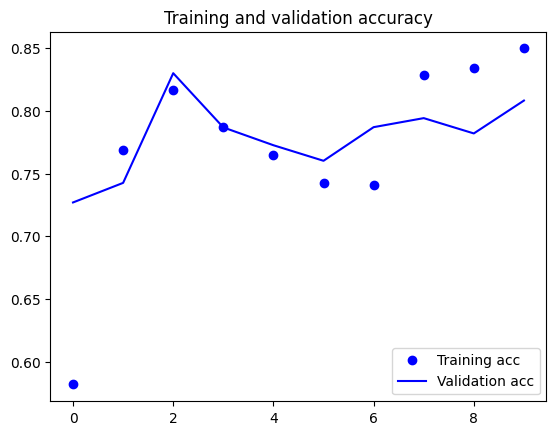

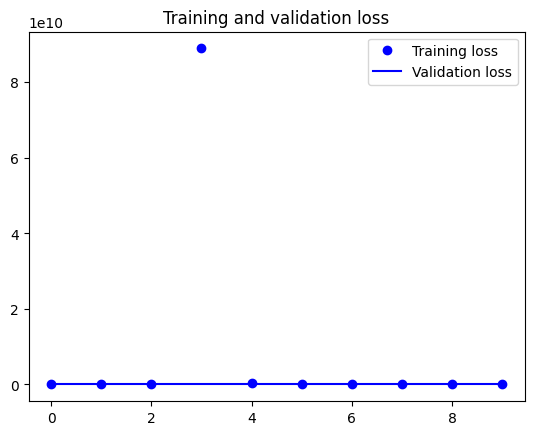

In [13]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [14]:
# score it on the TEST set - macro F1 is how we compare models (same as the capstone)
from sklearn.metrics import f1_score

probs = model.predict(input_test, verbose=0)
preds = (probs > 0.5).astype(int).ravel()
print('LSTM + GRU test macro F1:', round(f1_score(y_test, preds, average='macro'), 3))

LSTM + GRU test macro F1: 0.812


🔴
<!-- 🎙 DAVE TALKING POINTS — M5 · 10 — The monster: embedding + Conv1D + pooling + bidirectional + stacked
- Every tool at once, ten lines of code: Embedding(128) -> Conv1D(64, 3) -> MaxPooling1D(2) -> Bidirectional(LSTM(30), return_sequences) -> GRU(20) -> Dropout -> sigmoid.
- Walk the shapes: 100 x 128 -> Conv1D kernel 3 gives 98 x 64 -> pooling 49 x 64 (a shorter time series) -> bidirectional 49 x 60 (30 forward + 30 backward) -> GRU 20 -> 1.
- 1,332,381 parameters - slightly FEWER than the LSTM + GRU, and it wins. Bigger isn't the point.
- Loss curve: best validation loss 0.345 at epoch 4 of 10 - after that it overfits. EarlyStopping would have stopped there.
- TEST MACRO F1 0.842. Scoreboard: SimpleRNN 0.789 -> LSTM + GRU 0.812 -> monster 0.842.
- The architecture is arbitrary - the lesson is that the tools compose.
- Hand-off: this exact model is the capstone's build_monster(). Next we swap IMDB for real posts from Bluesky.
-->

# Monster!
Bidirectional layers, convolution, pooling, stacking, recurrent dropout.

In [15]:
from keras.layers import Conv1D, MaxPooling1D, Bidirectional, GRU
from keras.layers import Input
# define model
keras.utils.set_random_seed(5509)   # re-seed right before the build: same starting weights every run
model = Sequential()
model.add(Input(shape=(maxlen,)))
model.add(Embedding(max_features, 128))
model.add(Conv1D(filters=64, kernel_size=3))
model.add(MaxPooling1D(2))
model.add(Bidirectional(LSTM(30,
                            return_sequences=True, # remember, if stacking layers, you need to return sequences!
                            activation='relu',
                            recurrent_dropout=0.2)))
model.add(GRU(20, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 98, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 49, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 49, 60)         │        22,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 20)             │         4,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,332,381 (5.08 MB)

 Trainable params: 1,332,381 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


  1/157 ━━━━━━━━━━━━━━━━━━━━ 17:14 7s/step - acc: 0.4375 - loss: 0.6941

  2/157 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - acc: 0.4492 - loss: 0.6939

  3/157 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - acc: 0.4740 - loss: 0.6936

  4/157 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - acc: 0.4746 - loss: 0.6935

...

154/157 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - acc: 0.9747 - loss: 0.0758

155/157 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - acc: 0.9747 - loss: 0.0755

156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - acc: 0.9748 - loss: 0.0754

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - acc: 0.9748 - loss: 0.0753

157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - acc: 0.9748 - loss: 0.0753 - val_acc: 0.8416 - val_loss: 0.5417


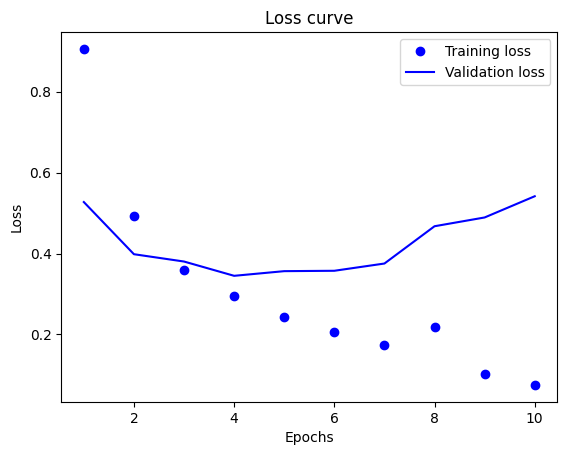

epochs run: 10 | best validation loss: 0.345 at epoch 4


In [16]:
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])

history = model.fit(input_train, y_train,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.2)

# loss curve - always look at this after a fit!
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Loss curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

best_epoch = val_loss.index(min(val_loss)) + 1
print('epochs run:', len(loss), '| best validation loss:', round(min(val_loss), 4), 'at epoch', best_epoch)

In [17]:
# score it on the TEST set - macro F1 is how we compare models (same as the capstone)
from sklearn.metrics import f1_score

probs = model.predict(input_test, verbose=0)
preds = (probs > 0.5).astype(int).ravel()
print('Monster    test macro F1:', round(f1_score(y_test, preds, average='macro'), 3))

Monster    test macro F1: 0.842
